# VQA_trainB_2_blip.ipynb
Dùng translation.json để chạy B1 zero-shot và B2 LoRA; dịch ngược EN→VI để đánh giá.

In [1]:
#Cell_0 - Kaggle-safe imports for B1/B2 using translation.json
# Notebook này dùng translation.json: B1 zero-shot, B2 LoRA fine-tuning, dịch ngược EN->VI để đánh giá.
import sys, subprocess, importlib.util, os, gc, json, random, warnings, math
from pathlib import Path
from typing import List, Dict, Any

def ensure_pkg(pkg, pip_name=None):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name or pkg])
ensure_pkg('peft', 'peft')
ensure_pkg('accelerate', 'accelerate')
ensure_pkg('sentencepiece', 'sentencepiece')

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
from transformers import BlipProcessor, BlipForQuestionAnswering, AutoTokenizer, AutoModelForSeq2SeqLM
from peft import LoraConfig, get_peft_model
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)


DEVICE: cuda


In [2]:
#!ls /kaggle/input/datasets/khangnhut/vqa-vietnameses-food-dataset
# !ls /kaggle/input/notebooks/khangnhut/vqa-trainb-1/translation_bridge

In [3]:
#Cell_1 - Config
# DATA_DIR: nơi chứa output đã dịch từ VQA_trainB_1_translation.ipynb
# - Có thể là /kaggle/working/translation_bridge nếu chạy B2_1 và B2_2 trong cùng notebook/session.
# - Có thể là /kaggle/input/... nếu bạn upload output B2_1 thành Kaggle Dataset.
CANDIDATE_DATA_DIRS = [
    Path('/kaggle/input/notebooks/khangnhut/vqa-trainb-1/'),
]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if (p / 'translation.json').exists()), CANDIDATE_DATA_DIRS[0])

# IMG_DIR: nơi chứa ảnh gốc từ Kaggle Dataset ảnh/processed VQA, tách riêng với DATA_DIR.
# Nếu tên dataset ảnh của bạn khác, chỉ cần sửa IMG_DIR ở đây, không sửa DATA_DIR.
CANDIDATE_IMG_DIRS = [
    Path('/kaggle/input/datasets/khangnhut/vqa-vietnameses-food-dataset/vietnamese_food_images_2k5/vietnamese_food_images_2k5'),
]
IMG_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists()), CANDIDATE_IMG_DIRS[0])

# B2_2 chỉ đọc đúng output do VQA_trainB_1_translation.ipynb tạo ra.
# Format bắt buộc: translation.json là LIST các dict có split/image_path/question_vi/answer_vi/question_en/answer_en.
# Không dùng file translations.json custom ở thư mục gốc vì format đó không đủ metadata ảnh/split để train/evaluate B1-B2.
CANDIDATE_TRANSLATION = [
    DATA_DIR / 'translation.json',
    DATA_DIR / 'translation_bridge' / 'translation.json',
    Path('/kaggle/working/translation_bridge/translation.json'),
]
TRANSLATION_JSON = next((p for p in CANDIDATE_TRANSLATION if p.exists()), CANDIDATE_TRANSLATION[0])
OUT_DIR = Path('/kaggle/working/checkpoints_B_translation'); OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'Salesforce/blip-vqa-base'
EN_VI_MODEL = 'Helsinki-NLP/opus-mt-en-vi'
BATCH_B1 = 8
BATCH_B2 = 2
GRAD_ACCUM_STEPS = 2
EPOCHS_B2 = 5
LR = 5e-5
WEIGHT_DECAY = 0.01
MAX_Q_LEN = 64
MAX_A_LEN = 16
MAX_NEW_TOKENS = 12
NUM_WORKERS = 0
USE_AMP = torch.cuda.is_available()
TRAIN_LIMIT = None
VAL_LIMIT = None
TEST_LIMIT = None
SEED = 42
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print('DATA_DIR (translated QA):', DATA_DIR)
print('IMG_DIR (image dataset):', IMG_DIR)
print('TRANSLATION_JSON:', TRANSLATION_JSON)
print('OUT_DIR:', OUT_DIR)


DATA_DIR (translated QA): /kaggle/input/notebooks/khangnhut/vqa-trainb-1
IMG_DIR (image dataset): /kaggle/input/datasets/khangnhut/vqa-vietnameses-food-dataset/vietnamese_food_images_2k5/vietnamese_food_images_2k5
TRANSLATION_JSON: /kaggle/input/notebooks/khangnhut/vqa-trainb-1/translation.json
OUT_DIR: /kaggle/working/checkpoints_B_translation


In [4]:
#Cell_2 - Utilities, dataset, path resolver
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.ipc_collect()

def normalize_answer(x): return str(x).strip().lower()
def exact(preds, refs): return sum(normalize_answer(p)==normalize_answer(r) for p,r in zip(preds,refs))/max(len(refs),1)
def soft(preds, refs):
    s=0
    for p,r in zip(preds,refs):
        p=normalize_answer(p); r=normalize_answer(r)
        s += 1 if p==r else (0.5 if p and r and (p in r or r in p) else 0)
    return s/max(len(refs),1)

def resolve_image_path(raw_path, image_id=None):
    # DATA_DIR chứa câu hỏi/answer đã dịch; IMG_DIR chứa ảnh. Không nối ảnh bằng DATA_DIR.
    img_dir = Path(IMG_DIR)
    data_dir = Path(DATA_DIR)  # chỉ dùng fallback nếu output B2_1 được đóng gói chung với ảnh.
    p = Path(str(raw_path))
    image_dirs = [
        img_dir,
        img_dir / 'vietnamese_food_images_2k5',
        img_dir / 'vietnamese_food_images',
        img_dir / 'vietnamese_food_images' / 'vietnamese_food_images',
        img_dir / 'vietnamese_food_images_2k5' / 'vietnamese_food_images_2k5',
        data_dir / 'vietnamese_food_images_2k5',
        data_dir / 'vietnamese_food_images',
    ]
    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        # image_path trong translation.json thường là vietnamese_food_images_2k5/image_xxx.jpg.
        # Thử IMG_DIR / relative_path trước, rồi IMG_DIR / filename để xử lý dataset ảnh chỉ chứa file ảnh trực tiếp.
        candidates.extend([img_dir / p, img_dir / p.name, p])
    candidates.extend([d / p.name for d in image_dirs])
    if image_id is not None and str(image_id).strip():
        candidates.extend([d / f'image_{image_id}.jpg' for d in image_dirs])
    seen = set(); uniq = []
    for candidate in candidates:
        s = str(candidate)
        if s not in seen:
            seen.add(s); uniq.append(candidate)
    for candidate in uniq:
        if candidate.exists(): return candidate
    raise FileNotFoundError(f'Cannot resolve image: {raw_path}. IMG_DIR={img_dir}. DATA_DIR={data_dir}. Tried: {[str(x) for x in uniq[:12]]}')

REQUIRED_B2_1_KEYS = {'split', 'image_path', 'question_vi', 'answer_vi', 'question_en', 'answer_en'}
VALID_SPLITS = {'train', 'val', 'test'}

def load_b2_1_translation_rows(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f'Không tìm thấy translation.json tại {path}. Hãy chạy VQA_trainB_1_translation.ipynb trước, '
            'hoặc upload Kaggle Dataset chứa đúng file translation.json do B2_1 tạo ra.'
        )
    obj = json.loads(path.read_text(encoding='utf-8'))
    if not isinstance(obj, list):
        raise ValueError(
            'B2_2 chỉ nhận translation.json đúng định dạng output của VQA_trainB_1_translation.ipynb: '
            'một LIST các dict. File hiện tại không hợp lệ; không dùng translations.json custom dạng dict/list text rời.'
        )
    if not obj:
        raise ValueError('translation.json rỗng. Hãy kiểm tra lại output của VQA_trainB_1_translation.ipynb.')

    bad = []
    normalized = []
    for i, r in enumerate(obj):
        if not isinstance(r, dict):
            bad.append((i, f'type={type(r).__name__}'))
            continue
        missing = sorted(REQUIRED_B2_1_KEYS - set(r.keys()))
        if missing:
            bad.append((i, f'missing={missing}'))
            continue
        if r.get('split') not in VALID_SPLITS:
            bad.append((i, f"invalid_split={r.get('split')!r}"))
            continue
        item = dict(r)
        for k in REQUIRED_B2_1_KEYS:
            item[k] = str(item.get(k, '')).strip()
        normalized.append(item)
    if bad:
        preview = bad[:10]
        raise ValueError(
            'translation.json không đúng format B2_1. Mỗi row cần các key: '
            f'{sorted(REQUIRED_B2_1_KEYS)}. Lỗi mẫu: {preview}'
        )
    split_counts = {s: sum(r.get('split') == s for r in normalized) for s in ['train','val','test']}
    missing_splits = [s for s,c in split_counts.items() if c == 0]
    if missing_splits:
        raise ValueError(f'translation.json thiếu split {missing_splits}. B2_1 cần export đủ train/val/test.')
    return normalized

rows = load_b2_1_translation_rows(TRANSLATION_JSON)
print('Rows:', len(rows), {s: sum(r.get('split')==s for r in rows) for s in ['train','val','test']})
print('Sample row keys:', sorted(rows[0].keys()))

class TranslationVQADataset(Dataset):
    def __init__(self, rows, split, limit=None):
        self.rows = [r for r in rows if r.get('split') == split]
        if limit is not None: self.rows = self.rows[:limit]
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows[i]
        return {
            'image': Image.open(resolve_image_path(r.get('image_path',''), r.get('image_id'))).convert('RGB'),
            'question_en': r.get('question_en',''),
            'answer_en': r.get('answer_en',''),
            'question_vi': r.get('question_vi',''),
            'answer_vi': r.get('answer_vi',''),
            'image_id': r.get('image_id',''),
            'class_id': r.get('class_id','unknown'),
            'question_type': r.get('question_type','unknown'),
        }

def collate_raw(batch): return {k:[b[k] for b in batch] for k in batch[0]}
def make_loader(split, batch, shuffle=False, limit=None):
    return DataLoader(TranslationVQADataset(rows, split, limit), batch_size=batch, shuffle=shuffle, collate_fn=collate_raw, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())


Rows: 22127 {'train': 17726, 'val': 2204, 'test': 2197}
Sample row keys: ['answer', 'answer_en', 'answer_source', 'answer_vi', 'answer_word_count', 'class_id', 'image_id', 'image_path', 'question', 'question_en', 'question_group', 'question_type', 'question_vi', 'raw_answer', 'row_id', 'sample_id', 'split']


In [5]:
#Cell_3 - EN -> VI translator for generated answers
translator_cache_path = OUT_DIR / 'en_vi_pred_cache.json'
translator_cache = json.loads(translator_cache_path.read_text(encoding='utf-8')) if translator_cache_path.exists() else {}

def load_en_vi():
    tok = AutoTokenizer.from_pretrained(EN_VI_MODEL)
    mdl = AutoModelForSeq2SeqLM.from_pretrained(EN_VI_MODEL).to(DEVICE).eval()
    return tok, mdl

def translate_en_to_vi(texts, batch_size=16):
    missing = list(dict.fromkeys([t for t in texts if t not in translator_cache]))
    if missing:
        tok, mdl = load_en_vi()
        with torch.no_grad():
            for i in tqdm(range(0, len(missing), batch_size), desc='translate pred en->vi'):
                batch = missing[i:i+batch_size]
                enc = tok(batch, return_tensors='pt', padding=True, truncation=True, max_length=MAX_A_LEN).to(DEVICE)
                gen = mdl.generate(**enc, max_new_tokens=MAX_A_LEN, num_beams=3)
                outs = tok.batch_decode(gen, skip_special_tokens=True)
                for src, tgt in zip(batch, outs): translator_cache[src] = tgt
        translator_cache_path.write_text(json.dumps(translator_cache, ensure_ascii=False, indent=2), encoding='utf-8')
        del tok, mdl
        clear_memory()
    return [translator_cache.get(t, t) for t in texts]


In [6]:
#Cell_4 - B1 zero-shot on English questions, translate predictions back to Vietnamese
clear_memory()
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForQuestionAnswering.from_pretrained(MODEL_NAME).to(DEVICE).eval()
test_dl = make_loader('test', BATCH_B1, shuffle=False, limit=TEST_LIMIT)
preds_en=[]; refs_en=[]; refs_vi=[]; meta=[]
with torch.no_grad():
    for b in tqdm(test_dl, desc='B1 zero-shot EN'):
        inputs = processor(b['image'], b['question_en'], return_tensors='pt', padding=True, truncation=True, max_length=MAX_Q_LEN).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            gen = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
        out = processor.batch_decode(gen, skip_special_tokens=True)
        preds_en += out; refs_en += b['answer_en']; refs_vi += b['answer_vi']
        for i,p in enumerate(out):
            meta.append({'image_id':b['image_id'][i], 'class_id':b['class_id'][i], 'question_type':b['question_type'][i], 'question_vi':b['question_vi'][i], 'question_en':b['question_en'][i], 'answer_vi':b['answer_vi'][i], 'answer_en':b['answer_en'][i], 'pred_en':p})
preds_vi = translate_en_to_vi(preds_en)
for m,pvi in zip(meta, preds_vi): m['pred_vi'] = pvi
metrics_B1 = {'exact_en': exact(preds_en, refs_en), 'soft_en': soft(preds_en, refs_en), 'exact_vi': exact(preds_vi, refs_vi), 'soft_vi': soft(preds_vi, refs_vi), 'n': len(refs_vi)}
(OUT_DIR/'B1_zero_shot').mkdir(exist_ok=True)
(OUT_DIR/'B1_zero_shot'/'predictions.json').write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')
(OUT_DIR/'B1_zero_shot'/'metrics.json').write_text(json.dumps(metrics_B1, ensure_ascii=False, indent=2), encoding='utf-8')
print(metrics_B1)
del model
clear_memory()


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/289M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

translate pred en->vi:   0%|          | 0/17 [00:00<?, ?it/s]

{'exact_en': 0.0, 'soft_en': 0.1301775147928994, 'exact_vi': 0.0, 'soft_vi': 0.0063723258989531175, 'n': 2197}


In [7]:
#Cell_5 - B2 LoRA model setup
def pick_lora_targets(model):
    names = [name for name, module in model.named_modules() if isinstance(module, torch.nn.Linear)]
    preferred = ['query','key','value','q_proj','k_proj','v_proj']
    targets = sorted({name.split('.')[-1] for name in names if any(k in name.lower() for k in preferred)})
    return targets or ['query','key','value']

clear_memory()
processor = BlipProcessor.from_pretrained(MODEL_NAME)
base_model = BlipForQuestionAnswering.from_pretrained(MODEL_NAME)
# Không bật gradient checkpointing cho BLIP + LoRA ở đây: một số version transformers/peft trên Kaggle
# có in-place op trên leaf tensor khi forward, gây lỗi
# RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.
# PEFT sẽ tự freeze base model và chỉ mở grad cho LoRA adapter sau get_peft_model().
if hasattr(base_model, 'config'):
    base_model.config.use_cache = False
LORA_TARGETS = pick_lora_targets(base_model)
print('LoRA targets:', LORA_TARGETS)
peft_config = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05, target_modules=LORA_TARGETS, bias='none')
model = get_peft_model(base_model, peft_config).to(DEVICE)
model.train()
model.print_trainable_parameters()


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LoRA targets: ['key', 'query', 'value']
trainable params: 1,769,472 || all params: 386,442,044 || trainable%: 0.4579


In [8]:
#Cell_6 - B2 LoRA fine-tuning on translated English QA
train_dl = make_loader('train', BATCH_B2, shuffle=True, limit=TRAIN_LIMIT)
val_dl = make_loader('val', BATCH_B2, shuffle=False, limit=VAL_LIMIT)
trainable_params = [p for p in model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
history=[]; best=-1; global_step=0
for ep in range(1, EPOCHS_B2+1):
    model.train(); total=0.0; seen=0; opt.zero_grad(set_to_none=True)
    for step,b in enumerate(tqdm(train_dl, desc=f'B2 LoRA train e{ep}'), start=1):
        inputs = processor(images=b['image'], text=b['question_en'], text_target=b['answer_en'], return_tensors='pt', padding=True, truncation=True, max_length=MAX_Q_LEN).to(DEVICE)
        if 'labels' in inputs: inputs['labels'] = inputs['labels'][:, :MAX_A_LEN]
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            loss = model(**inputs).loss / GRAD_ACCUM_STEPS
        if not torch.isfinite(loss):
            print('[WARN] non-finite loss, skip'); opt.zero_grad(set_to_none=True); clear_memory(); continue
        scaler.scale(loss).backward()
        total += float(loss.detach().cpu()) * GRAD_ACCUM_STEPS * len(b['answer_en']); seen += len(b['answer_en'])
        if step % GRAD_ACCUM_STEPS == 0 or step == len(train_dl):
            scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(trainable_params, 1.0); scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True); global_step += 1
        del inputs, loss
    clear_memory()
    model.eval(); preds_en=[]; refs_en=[]; refs_vi=[]
    with torch.no_grad():
        for b in tqdm(val_dl, desc=f'B2 val e{ep}'):
            inputs = processor(b['image'], b['question_en'], return_tensors='pt', padding=True, truncation=True, max_length=MAX_Q_LEN).to(DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                gen = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
            preds_en += processor.batch_decode(gen, skip_special_tokens=True); refs_en += b['answer_en']; refs_vi += b['answer_vi']
            del inputs, gen
    preds_vi = translate_en_to_vi(preds_en)
    rec = {'epoch': ep, 'train_loss': total/max(seen,1), 'val_exact_en': exact(preds_en, refs_en), 'val_soft_en': soft(preds_en, refs_en), 'val_exact_vi': exact(preds_vi, refs_vi), 'val_soft_vi': soft(preds_vi, refs_vi), 'global_step': global_step}
    print(rec); history.append(rec)
    (OUT_DIR/'B2_history.json').write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding='utf-8')
    model.save_pretrained(OUT_DIR/'B2_lora_last'); processor.save_pretrained(OUT_DIR/'B2_lora_last')
    if rec['val_soft_vi'] > best:
        best = rec['val_soft_vi']; model.save_pretrained(OUT_DIR/'B2_lora_best'); processor.save_pretrained(OUT_DIR/'B2_lora_best')
    clear_memory()


B2 LoRA train e1:   0%|          | 0/8863 [00:00<?, ?it/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


B2 val e1:   0%|          | 0/1102 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

B2 val e5:   0%|          | 0/1102 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


translate pred en->vi:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': 2.45739764684054, 'val_exact_en': 0.06851179673321234, 'val_soft_en': 0.06987295825771325, 'val_exact_vi': 0.0009074410163339383, 'val_soft_vi': 0.0018148820326678765, 'global_step': 22160}


In [9]:
#Cell_7 - Final B2 test evaluation with Vietnamese back-translation
best_dir = OUT_DIR / 'B2_lora_best'
# Nếu vừa train trong session, dùng model hiện tại; cell này đánh giá test và lưu predictions.
test_dl = make_loader('test', BATCH_B2, shuffle=False, limit=TEST_LIMIT)
model.eval(); preds_en=[]; refs_en=[]; refs_vi=[]; rows_out=[]
with torch.no_grad():
    for b in tqdm(test_dl, desc='B2 test'):
        inputs = processor(b['image'], b['question_en'], return_tensors='pt', padding=True, truncation=True, max_length=MAX_Q_LEN).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            gen = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
        out = processor.batch_decode(gen, skip_special_tokens=True)
        preds_en += out; refs_en += b['answer_en']; refs_vi += b['answer_vi']
        for i,p in enumerate(out): rows_out.append({'image_id':b['image_id'][i], 'class_id':b['class_id'][i], 'question_type':b['question_type'][i], 'question_vi':b['question_vi'][i], 'question_en':b['question_en'][i], 'answer_vi':b['answer_vi'][i], 'answer_en':b['answer_en'][i], 'pred_en':p})
        del inputs, gen
preds_vi = translate_en_to_vi(preds_en)
for m,pvi in zip(rows_out, preds_vi): m['pred_vi'] = pvi
metrics_B2 = {'exact_en': exact(preds_en, refs_en), 'soft_en': soft(preds_en, refs_en), 'exact_vi': exact(preds_vi, refs_vi), 'soft_vi': soft(preds_vi, refs_vi), 'n': len(refs_vi)}
(OUT_DIR/'B2_lora_test').mkdir(exist_ok=True)
(OUT_DIR/'B2_lora_test'/'predictions.json').write_text(json.dumps(rows_out, ensure_ascii=False, indent=2), encoding='utf-8')
(OUT_DIR/'B2_lora_test'/'metrics.json').write_text(json.dumps(metrics_B2, ensure_ascii=False, indent=2), encoding='utf-8')
print(metrics_B2)


B2 test:   0%|          | 0/1099 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


translate pred en->vi:   0%|          | 0/64 [00:00<?, ?it/s]

{'exact_en': 0.06053709604005462, 'soft_en': 0.061219845243513885, 'exact_vi': 0.0009103322712790169, 'soft_vi': 0.0013654984069185253, 'n': 2197}


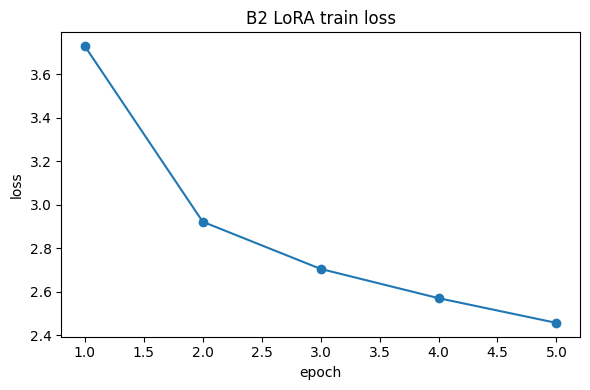

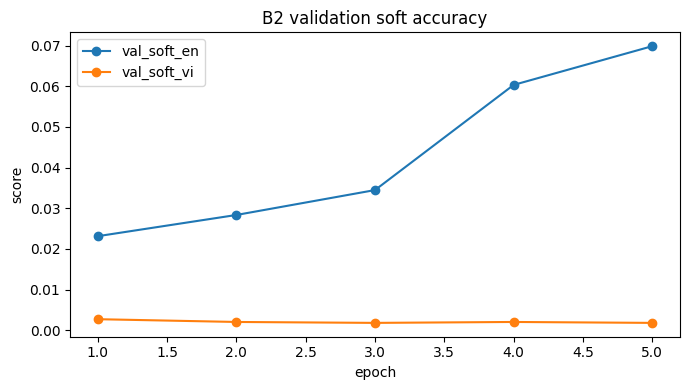

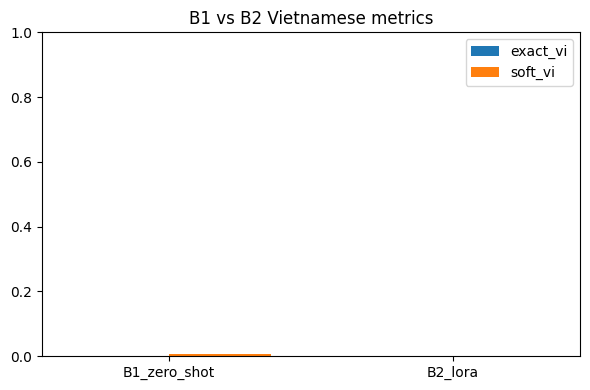

In [10]:
#Cell_8 - Plots: B2 loss/metrics and B1 vs B2 comparison
plots_dir = OUT_DIR / 'plots'; plots_dir.mkdir(exist_ok=True)
if history:
    plt.figure(figsize=(6,4)); plt.plot([h['epoch'] for h in history], [h['train_loss'] for h in history], marker='o'); plt.title('B2 LoRA train loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.tight_layout(); plt.savefig(plots_dir/'B2_train_loss.png', dpi=160); plt.show()
    plt.figure(figsize=(7,4));
    plt.plot([h['epoch'] for h in history], [h['val_soft_en'] for h in history], marker='o', label='val_soft_en')
    plt.plot([h['epoch'] for h in history], [h['val_soft_vi'] for h in history], marker='o', label='val_soft_vi')
    plt.title('B2 validation soft accuracy'); plt.xlabel('epoch'); plt.ylabel('score'); plt.legend(); plt.tight_layout(); plt.savefig(plots_dir/'B2_val_soft.png', dpi=160); plt.show()
try:
    names = ['B1_zero_shot', 'B2_lora']
    soft_vi = [metrics_B1['soft_vi'], metrics_B2['soft_vi']]
    exact_vi = [metrics_B1['exact_vi'], metrics_B2['exact_vi']]
    x = range(len(names))
    plt.figure(figsize=(6,4)); plt.bar([i-0.18 for i in x], exact_vi, width=0.36, label='exact_vi'); plt.bar([i+0.18 for i in x], soft_vi, width=0.36, label='soft_vi'); plt.xticks(list(x), names); plt.ylim(0,1); plt.title('B1 vs B2 Vietnamese metrics'); plt.legend(); plt.tight_layout(); plt.savefig(plots_dir/'B1_vs_B2_metrics_vi.png', dpi=160); plt.show()
except Exception as e:
    print('Skip comparison plot:', e)


In [ ]:
#Cell_9 - Demo B1 zero-shot vs B2 LoRA from /kaggle/working output
# Chạy cell này sau khi train xong B2 trong cùng session hoặc khi /kaggle/working còn checkpoint.
# Nếu upload ảnh vào /kaggle/working, sửa DEMO_IMAGE_PATH_WORKING cho đúng tên file.
import io, gc
from pathlib import Path
from PIL import Image
from IPython.display import display
from peft import PeftModel

DEMO_IMAGE_PATH_WORKING = Path('/kaggle/working/demo.jpg')
DEMO_QUESTION_EN = 'What food is in the image?'
DEMO_QUESTION_VI = 'Món ăn trong ảnh là gì?'
LORA_WORKING_DIR = OUT_DIR / 'B2_lora_best'
DEMO_MAX_NEW_TOKENS = MAX_NEW_TOKENS if 'MAX_NEW_TOKENS' in globals() else 20

def demo_clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def demo_translate_en_to_vi(text):
    if 'translate_en_to_vi' in globals():
        return translate_en_to_vi([text])[0]
    return text

def demo_load_image(image_path):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f'Không tìm thấy ảnh demo: {image_path}. Hãy upload ảnh vào /kaggle/working hoặc sửa path.')
    return Image.open(image_path).convert('RGB')

def demo_answer_blip(model, processor, image, question_en):
    inputs = processor(images=image, text=question_en, return_tensors='pt', padding=True, truncation=True).to(DEVICE)
    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=DEMO_MAX_NEW_TOKENS)
    return processor.batch_decode(gen, skip_special_tokens=True)[0].strip()

def demo_compare_blip_lora(image_path, question_en=DEMO_QUESTION_EN, question_vi=DEMO_QUESTION_VI, lora_dir=LORA_WORKING_DIR):
    image = demo_load_image(image_path)
    display(image.resize((320, 320)))
    print('Question VI:', question_vi)
    print('Question EN:', question_en)
    print('LoRA dir:', lora_dir)

    demo_processor = BlipProcessor.from_pretrained(MODEL_NAME)

    # B1 zero-shot BLIP
    zero_model = BlipForQuestionAnswering.from_pretrained(MODEL_NAME).to(DEVICE).eval()
    zero_en = demo_answer_blip(zero_model, demo_processor, image, question_en)
    del zero_model
    demo_clear_memory()

    # B2 LoRA fine-tuned BLIP
    lora_dir = Path(lora_dir)
    if not lora_dir.exists():
        raise FileNotFoundError(f'Không tìm thấy LoRA checkpoint tại {lora_dir}. Hãy chạy Cell_6 train B2 hoặc kiểm tra OUT_DIR.')
    base_model = BlipForQuestionAnswering.from_pretrained(MODEL_NAME).to(DEVICE)
    lora_model = PeftModel.from_pretrained(base_model, str(lora_dir)).to(DEVICE).eval()
    lora_en = demo_answer_blip(lora_model, demo_processor, image, question_en)
    del lora_model, base_model
    demo_clear_memory()

    result = {
        'question_vi': question_vi,
        'question_en': question_en,
        'zero_shot_pred_en': zero_en,
        'zero_shot_pred_vi': demo_translate_en_to_vi(zero_en),
        'lora_pred_en': lora_en,
        'lora_pred_vi': demo_translate_en_to_vi(lora_en),
    }
    print('\n=== DEMO RESULT: B1 ZERO-SHOT vs B2 LoRA FROM /kaggle/working ===')
    for k, v in result.items():
        print(f'{k}: {v}')
    return result

# Bỏ comment để chạy:
# result_working = demo_compare_blip_lora(DEMO_IMAGE_PATH_WORKING)


In [ ]:
#Cell_10 - Demo B1 zero-shot vs B2 LoRA from Kaggle Input dataset
# Dùng khi đã add output B2 LoRA thành Kaggle Dataset Input.
# Sửa candidates bên dưới theo tên dataset thật của bạn nếu cần.
from pathlib import Path

LORA_INPUT_CANDIDATES = [
    Path('/kaggle/input/trainb-lora-output/checkpoints_B_translation/B2_lora_best'),
    Path('/kaggle/input/trainb-lora-output/B2_lora_best'),
    Path('/kaggle/input/dataset/checkpoints_B_translation/B2_lora_best'),
    Path('/kaggle/input/dataset/B2_lora_best'),
    Path('/kaggle/input/vqa-trainb-output/checkpoints_B_translation/B2_lora_best'),
    Path('/kaggle/input/vqa-trainb-output/B2_lora_best'),
]
LORA_INPUT_DIR = next((p for p in LORA_INPUT_CANDIDATES if p.exists()), LORA_INPUT_CANDIDATES[0])

DEMO_INPUT_IMAGE_CANDIDATES = [
    Path('/kaggle/input/dataset/VQA_Demo/demo.jpg'),
    Path('/kaggle/input/dataset/demo.jpg'),
    Path('/kaggle/input/vqa-demo/VQA_Demo/demo.jpg'),
    Path('/kaggle/input/vqa-demo/demo.jpg'),
]
DEMO_IMAGE_PATH_INPUT = next((p for p in DEMO_INPUT_IMAGE_CANDIDATES if p.exists()), DEMO_INPUT_IMAGE_CANDIDATES[0])
DEMO_INPUT_QUESTION_EN = 'What food is in the image?'
DEMO_INPUT_QUESTION_VI = 'Món ăn trong ảnh là gì?'

def demo_compare_blip_lora_from_input(image_path=DEMO_IMAGE_PATH_INPUT, question_en=DEMO_INPUT_QUESTION_EN, question_vi=DEMO_INPUT_QUESTION_VI, lora_dir=LORA_INPUT_DIR):
    print('Using image:', image_path)
    print('Using LoRA :', lora_dir)
    return demo_compare_blip_lora(
        image_path=image_path,
        question_en=question_en,
        question_vi=question_vi,
        lora_dir=lora_dir,
    )

# Bỏ comment để chạy:
# result_input = demo_compare_blip_lora_from_input()
